<h1 align="center" style="color:green">Fraud Detection Project Notebook</h1>

In [1]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/shivamb/vehicle-claim-fraud-detection/fraud_oracle.csv


#### Importing libraries and loading data

In [2]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

In [3]:
df = pd.read_csv("/kaggle/input/datasets/shivamb/vehicle-claim-fraud-detection/fraud_oracle.csv")
df.head()

,Month,WeekOfMonth,DayOfWeek,Make,AccidentArea,DayOfWeekClaimed,MonthClaimed,WeekOfMonthClaimed,Sex,MaritalStatus,...,AgeOfVehicle,AgeOfPolicyHolder,PoliceReportFiled,WitnessPresent,AgentType,NumberOfSuppliments,AddressChange_Claim,NumberOfCars,Year,BasePolicy
0,Dec,5,Wednesday,Honda,Urban,Tuesday,Jan,1,Female,Single,...,3 years,26 to 30,No,No,External,none,1 year,3 to 4,1994,Liability
1,Jan,3,Wednesday,Honda,Urban,Monday,Jan,4,Male,Single,...,6 years,31 to 35,Yes,No,External,none,no change,1 vehicle,1994,Collision
2,Oct,5,Friday,Honda,Urban,Thursday,Nov,2,Male,Married,...,7 years,41 to 50,No,No,External,none,no change,1 vehicle,1994,Collision
3,Jun,2,Saturday,Toyota,Rural,Friday,Jul,1,Male,Married,...,more than 7,51 to 65,Yes,No,External,more than 5,no change,1 vehicle,1994,Liability
4,Jan,5,Monday,Honda,Urban,Tuesday,Feb,2,Female,Single,...,5 years,31 to 35,No,No,External,none,no change,1 vehicle,1994,Collision


#### Remaining columns

In [4]:
print('Columns:')
original_columns = df.columns
original_columns

Columns:


Index(['Month', 'WeekOfMonth', 'DayOfWeek', 'Make', 'AccidentArea',
       'DayOfWeekClaimed', 'MonthClaimed', 'WeekOfMonthClaimed', 'Sex',
       'MaritalStatus', 'Age', 'Fault', 'PolicyType', 'VehicleCategory',
       'VehiclePrice', 'FraudFound_P', 'PolicyNumber', 'RepNumber',
       'Deductible', 'DriverRating', 'Days_Policy_Accident',
       'Days_Policy_Claim', 'PastNumberOfClaims', 'AgeOfVehicle',
       'AgeOfPolicyHolder', 'PoliceReportFiled', 'WitnessPresent', 'AgentType',
       'NumberOfSuppliments', 'AddressChange_Claim', 'NumberOfCars', 'Year',
       'BasePolicy'],
      dtype='object')

In [5]:
import re
df.columns = [re.sub(r'(?<!^)(?=[A-Z])', '_', col).lower() for col in original_columns]
df.columns = df.columns.str.replace('__', '_')
df.columns

Index(['month', 'week_of_month', 'day_of_week', 'make', 'accident_area',
       'day_of_week_claimed', 'month_claimed', 'week_of_month_claimed', 'sex',
       'marital_status', 'age', 'fault', 'policy_type', 'vehicle_category',
       'vehicle_price', 'fraud_found_p', 'policy_number', 'rep_number',
       'deductible', 'driver_rating', 'days_policy_accident',
       'days_policy_claim', 'past_number_of_claims', 'age_of_vehicle',
       'age_of_policy_holder', 'police_report_filed', 'witness_present',
       'agent_type', 'number_of_suppliments', 'address_change_claim',
       'number_of_cars', 'year', 'base_policy'],
      dtype='object')

In [6]:
df.head()

,month,week_of_month,day_of_week,make,accident_area,day_of_week_claimed,month_claimed,week_of_month_claimed,sex,marital_status,...,age_of_vehicle,age_of_policy_holder,police_report_filed,witness_present,agent_type,number_of_suppliments,address_change_claim,number_of_cars,year,base_policy
0,Dec,5,Wednesday,Honda,Urban,Tuesday,Jan,1,Female,Single,...,3 years,26 to 30,No,No,External,none,1 year,3 to 4,1994,Liability
1,Jan,3,Wednesday,Honda,Urban,Monday,Jan,4,Male,Single,...,6 years,31 to 35,Yes,No,External,none,no change,1 vehicle,1994,Collision
2,Oct,5,Friday,Honda,Urban,Thursday,Nov,2,Male,Married,...,7 years,41 to 50,No,No,External,none,no change,1 vehicle,1994,Collision
3,Jun,2,Saturday,Toyota,Rural,Friday,Jul,1,Male,Married,...,more than 7,51 to 65,Yes,No,External,more than 5,no change,1 vehicle,1994,Liability
4,Jan,5,Monday,Honda,Urban,Tuesday,Feb,2,Female,Single,...,5 years,31 to 35,No,No,External,none,no change,1 vehicle,1994,Collision


#### Shape and Info

In [7]:
print(f'Shape: {df.shape}')
print(f"\nDataset Information:\n")
df.info()

Shape: (15420, 33)

Dataset Information:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15420 entries, 0 to 15419
Data columns (total 33 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   month                  15420 non-null  object
 1   week_of_month          15420 non-null  int64 
 2   day_of_week            15420 non-null  object
 3   make                   15420 non-null  object
 4   accident_area          15420 non-null  object
 5   day_of_week_claimed    15420 non-null  object
 6   month_claimed          15420 non-null  object
 7   week_of_month_claimed  15420 non-null  int64 
 8   sex                    15420 non-null  object
 9   marital_status         15420 non-null  object
 10  age                    15420 non-null  int64 
 11  fault                  15420 non-null  object
 12  policy_type            15420 non-null  object
 13  vehicle_category       15420 non-null  object
 14  vehicle_price          15420

In [8]:
df['fraud_found_p'].value_counts()

fraud_found_p
0    14497
1      923
Name: count, dtype: int64

In [9]:
X = df.drop(columns=['fraud_found_p'])
y = df['fraud_found_p']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print(f'Train set: {y_train.value_counts(normalize=True)}\n')
print(f'Test set: {y_test.value_counts(normalize=True)}')

Train set: fraud_found_p
0    0.940175
1    0.059825
Name: proportion, dtype: float64

Test set: fraud_found_p
0    0.940013
1    0.059987
Name: proportion, dtype: float64


### Note:
- Fraud rate: 923 / (14497 + 923) = ~5.99%, so roughly 1 in 17 claims is fraudulent. This isn't as extreme as some fraud datasets (some go below 1%)
- I will use `Stratified split`. With only 923 positive cases total, a random 80/20 split could easily land me with too few or unevenly distributed fraud cases in the test set.

In [10]:
df_train = pd.concat([X_train,y_train], axis=1)
df_test = pd.concat([X_test, y_test], axis =1)
df_train.shape, df_test.shape

((12336, 33), (3084, 33))

<h1 style="color:green">Data cleaning & Preprocessing</h1>

- Null values

In [11]:
df_train.isnull().sum()

month                    0
week_of_month            0
day_of_week              0
make                     0
accident_area            0
day_of_week_claimed      0
month_claimed            0
week_of_month_claimed    0
sex                      0
marital_status           0
age                      0
fault                    0
policy_type              0
vehicle_category         0
vehicle_price            0
policy_number            0
rep_number               0
deductible               0
driver_rating            0
days_policy_accident     0
days_policy_claim        0
past_number_of_claims    0
age_of_vehicle           0
age_of_policy_holder     0
police_report_filed      0
witness_present          0
agent_type               0
number_of_suppliments    0
address_change_claim     0
number_of_cars           0
year                     0
base_policy              0
fraud_found_p            0
dtype: int64

- Duplicate values

In [12]:
df_train.duplicated().sum()

np.int64(0)

- There are no null or duplicate values

In [13]:
df_train.describe(include='all')

,month,week_of_month,day_of_week,make,accident_area,day_of_week_claimed,month_claimed,week_of_month_claimed,sex,marital_status,...,age_of_policy_holder,police_report_filed,witness_present,agent_type,number_of_suppliments,address_change_claim,number_of_cars,year,base_policy,fraud_found_p
count,12336,12336.000000,12336,12336,12336,12336,12336,12336.000000,12336,12336,...,12336,12336,12336,12336,12336,12336,12336,12336.000000,12336,12336.000000
unique,12,NaN,7,19,2,8,13,NaN,2,4,...,9,2,2,2,4,5,5,NaN,3,NaN
top,May,NaN,Monday,Pontiac,Urban,Monday,Jan,NaN,Male,Married,...,31 to 35,No,No,External,none,no change,1 vehicle,NaN,Collision,NaN
freq,1108,NaN,2120,3065,11024,3021,1154,NaN,10417,8462,...,4468,12004,12266,12132,5577,11441,11417,NaN,4793,NaN
mean,NaN,2.789640,NaN,NaN,NaN,NaN,NaN,2.701443,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1994.861057,NaN,0.059825
std,NaN,1.282198,NaN,NaN,NaN,NaN,NaN,1.254466,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.802603,NaN,0.237172
min,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1994.000000,NaN,0.000000
25%,NaN,2.000000,NaN,NaN,NaN,NaN,NaN,2.000000,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1994.000000,NaN,0.000000
50%,NaN,3.000000,NaN,NaN,NaN,NaN,NaN,3.000000,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1995.000000,NaN,0.000000
75%,NaN,4.000000,NaN,NaN,NaN,NaN,NaN,4.000000,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1996.000000,NaN,0.000000


In [14]:

def find_unique_values(cols):
    unique = {col: df[col].unique() for col in cols}
    return unique

columns = df.columns
find_unique_values(columns)

{'month': array(['Dec', 'Jan', 'Oct', 'Jun', 'Feb', 'Nov', 'Apr', 'Mar', 'Aug',
        'Jul', 'May', 'Sep'], dtype=object),
 'week_of_month': array([5, 3, 2, 4, 1]),
 'day_of_week': array(['Wednesday', 'Friday', 'Saturday', 'Monday', 'Tuesday', 'Sunday',
        'Thursday'], dtype=object),
 'make': array(['Honda', 'Toyota', 'Ford', 'Mazda', 'Chevrolet', 'Pontiac',
        'Accura', 'Dodge', 'Mercury', 'Jaguar', 'Nisson', 'VW', 'Saab',
        'Saturn', 'Porche', 'BMW', 'Mecedes', 'Ferrari', 'Lexus'],
       dtype=object),
 'accident_area': array(['Urban', 'Rural'], dtype=object),
 'day_of_week_claimed': array(['Tuesday', 'Monday', 'Thursday', 'Friday', 'Wednesday', 'Saturday',
        'Sunday', '0'], dtype=object),
 'month_claimed': array(['Jan', 'Nov', 'Jul', 'Feb', 'Mar', 'Dec', 'Apr', 'Aug', 'May',
        'Jun', 'Sep', 'Oct', '0'], dtype=object),
 'week_of_month_claimed': array([1, 4, 2, 3, 5]),
 'sex': array(['Female', 'Male'], dtype=object),
 'marital_status': array(['Single', '

## Columns that need changes
- `month_claimed`: I found one row with a value of zero, so I removed it.
- `age`: I found 250 rows with an age of 0 and replaced those values with the median age.
- `vehicle_price`, `age_of_vehicle`: Replaced the bins with ordinal numbers
  
**Note:**

Identified unconventional spellings in `make` (**Accura, Nisson, Mecedes, Porche**). Verified that no correctly spelt duplicates exist for these values, so left as-is. No risk of category fragmentation during encoding.

In [15]:
df_train[df_train['month_claimed'] == '0']

,month,week_of_month,day_of_week,make,accident_area,day_of_week_claimed,month_claimed,week_of_month_claimed,sex,marital_status,...,age_of_policy_holder,police_report_filed,witness_present,agent_type,number_of_suppliments,address_change_claim,number_of_cars,year,base_policy,fraud_found_p
1516,Jul,2,Monday,Honda,Rural,0,0,1,Male,Single,...,16 to 17,No,No,External,none,no change,1 vehicle,1994,All Perils,0


In [16]:
df_train.shape

(12336, 33)

In [17]:
df_train = df_train[df_train['month_claimed'] != '0']
df_train.shape

(12335, 33)

In [18]:
df_test[df_test['month_claimed'] == '0']

,month,week_of_month,day_of_week,make,accident_area,day_of_week_claimed,month_claimed,week_of_month_claimed,sex,marital_status,...,age_of_policy_holder,police_report_filed,witness_present,agent_type,number_of_suppliments,address_change_claim,number_of_cars,year,base_policy,fraud_found_p


In [19]:
df_train[df_train['age'] == 0]

,month,week_of_month,day_of_week,make,accident_area,day_of_week_claimed,month_claimed,week_of_month_claimed,sex,marital_status,...,age_of_policy_holder,police_report_filed,witness_present,agent_type,number_of_suppliments,address_change_claim,number_of_cars,year,base_policy,fraud_found_p
3041,Apr,4,Friday,Honda,Urban,Tuesday,Apr,4,Male,Single,...,16 to 17,No,No,External,none,no change,1 vehicle,1994,All Perils,1
12020,Dec,4,Thursday,Honda,Urban,Tuesday,Jan,1,Male,Single,...,16 to 17,No,No,External,none,no change,1 vehicle,1996,Liability,0
7269,Feb,4,Saturday,Honda,Urban,Monday,Feb,5,Male,Single,...,16 to 17,No,No,External,none,no change,1 vehicle,1995,Liability,0
493,Mar,3,Tuesday,Honda,Urban,Wednesday,Mar,3,Male,Single,...,16 to 17,No,No,External,none,no change,1 vehicle,1994,All Perils,0
7613,May,2,Wednesday,Honda,Rural,Friday,May,3,Male,Single,...,16 to 17,Yes,No,External,none,no change,1 vehicle,1995,Liability,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10228,Mar,1,Wednesday,Honda,Rural,Wednesday,Mar,1,Male,Single,...,16 to 17,No,No,External,none,no change,1 vehicle,1995,Collision,0
7989,Feb,2,Tuesday,Honda,Urban,Tuesday,Apr,2,Male,Single,...,16 to 17,No,No,External,none,no change,1 vehicle,1995,All Perils,0
13553,Dec,2,Wednesday,Honda,Urban,Thursday,Dec,3,Male,Single,...,16 to 17,No,No,External,none,no change,1 vehicle,1996,All Perils,0
2103,Mar,3,Thursday,Honda,Urban,Thursday,Mar,3,Male,Single,...,16 to 17,No,No,External,none,no change,1 vehicle,1994,Collision,1


In [20]:
df_train[df_train['age'] == 0]['fraud_found_p'].value_counts()

fraud_found_p
0    224
1     26
Name: count, dtype: int64

In [21]:
df_test[df_test['age'] == 0]['fraud_found_p'].value_counts()

fraud_found_p
0    64
1     5
Name: count, dtype: int64

In [22]:
median_age = df_train.loc[df_train['age'] != 0, 'age'].median()
df_train['age'] = df_train['age'].replace(0, median_age)
df_train['age'].unique()

array([23, 34, 45, 40, 28, 32, 55, 26, 53, 35, 18, 36, 39, 61, 31, 33, 30,
       29, 59, 65, 46, 22, 54, 37, 49, 43, 50, 60, 48, 66, 25, 52, 27, 64,
       41, 57, 72, 58, 47, 20, 38, 69, 24, 77, 44, 42, 70, 76, 74, 80, 71,
       62, 51, 21, 79, 63, 56, 16, 73, 67, 75, 68, 78, 19, 17])

In [23]:
median_age = df_test.loc[df_test['age'] != 0, 'age'].median()
df_test['age'] = df_test['age'].replace(0, median_age)

In [24]:
df_train['vehicle_price'].unique(), df['age_of_vehicle'].unique()

(array(['20000 to 29000', '40000 to 59000', 'less than 20000',
        '30000 to 39000', 'more than 69000', '60000 to 69000'],
       dtype=object),
 array(['3 years', '6 years', '7 years', 'more than 7', '5 years', 'new',
        '4 years', '2 years'], dtype=object))

In [25]:
vehicle_price_map = {
    'less than 20000': 0,
    '20000 to 29000': 1,
    '30000 to 39000': 2,
    '40000 to 59000': 3,
    '60000 to 69000': 4,
    'more than 69000': 5
}
age_of_vehicle_map = {
    'new': 0,
    '2 years': 1,
    '3 years': 2,
    '4 years': 3,
    '5 years': 4,
    '6 years': 5,
    '7 years': 6,
    'more than 7': 7
}
df_train['vehicle_price'] = df_train['vehicle_price'].map(vehicle_price_map)
df_train['age_of_vehicle'] = df_train['age_of_vehicle'].map(age_of_vehicle_map)

In [26]:
df_test['vehicle_price'] = df_test['vehicle_price'].map(vehicle_price_map)
df_test['age_of_vehicle'] = df_test['age_of_vehicle'].map(age_of_vehicle_map)

In [27]:
df_train[['vehicle_price', 'age_of_vehicle']].isna().sum()
df_test[['vehicle_price', 'age_of_vehicle']].isna().sum()

vehicle_price     0
age_of_vehicle    0
dtype: int64

<h1 style="color:green">Exploratory data analysis</h1>

In [28]:
df_train.columns

Index(['month', 'week_of_month', 'day_of_week', 'make', 'accident_area',
       'day_of_week_claimed', 'month_claimed', 'week_of_month_claimed', 'sex',
       'marital_status', 'age', 'fault', 'policy_type', 'vehicle_category',
       'vehicle_price', 'policy_number', 'rep_number', 'deductible',
       'driver_rating', 'days_policy_accident', 'days_policy_claim',
       'past_number_of_claims', 'age_of_vehicle', 'age_of_policy_holder',
       'police_report_filed', 'witness_present', 'agent_type',
       'number_of_suppliments', 'address_change_claim', 'number_of_cars',
       'year', 'base_policy', 'fraud_found_p'],
      dtype='object')

In [29]:
df_train.groupby('rep_number')['fraud_found_p'].mean().sort_values()

rep_number
5     0.048223
12    0.048285
14    0.050340
15    0.050453
4     0.054886
8     0.056653
16    0.057895
13    0.058156
2     0.058978
11    0.062745
1     0.064039
3     0.064516
9     0.066250
10    0.068831
6     0.072193
7     0.073113
Name: fraud_found_p, dtype: float64

In [30]:
target_col = 'fraud_found_p'

numeric_cols = [
    'age',
    'vehicle_price',
    'age_of_vehicle',
    'deductible',
    'driver_rating',
    'year',
    'week_of_month',
    'week_of_month_claimed'
]

categorical_cols = [
    'month', 'day_of_week', 'make', 'accident_area','day_of_week_claimed', 
    'month_claimed','sex', 'marital_status', 'fault', 'policy_type', 
    'vehicle_category','police_report_filed', 'witness_present', 'agent_type',
    'base_policy','days_policy_accident', 'days_policy_claim', 'past_number_of_claims',
    'age_of_policy_holder', 'number_of_suppliments', 'address_change_claim',
    'number_of_cars'
]

# excluded entirely:
# policy_number   -> unique ID, not a feature
# fraud_found_p   -> target variable
# rep_number      -> checked separately (16 reps, fraud rate 0.04-0.07, uniform, no signal) — excluded from feature set

## Univariate & Bivariate analysis

### Univariate - numeric
- Hist plot
- kde plot
  

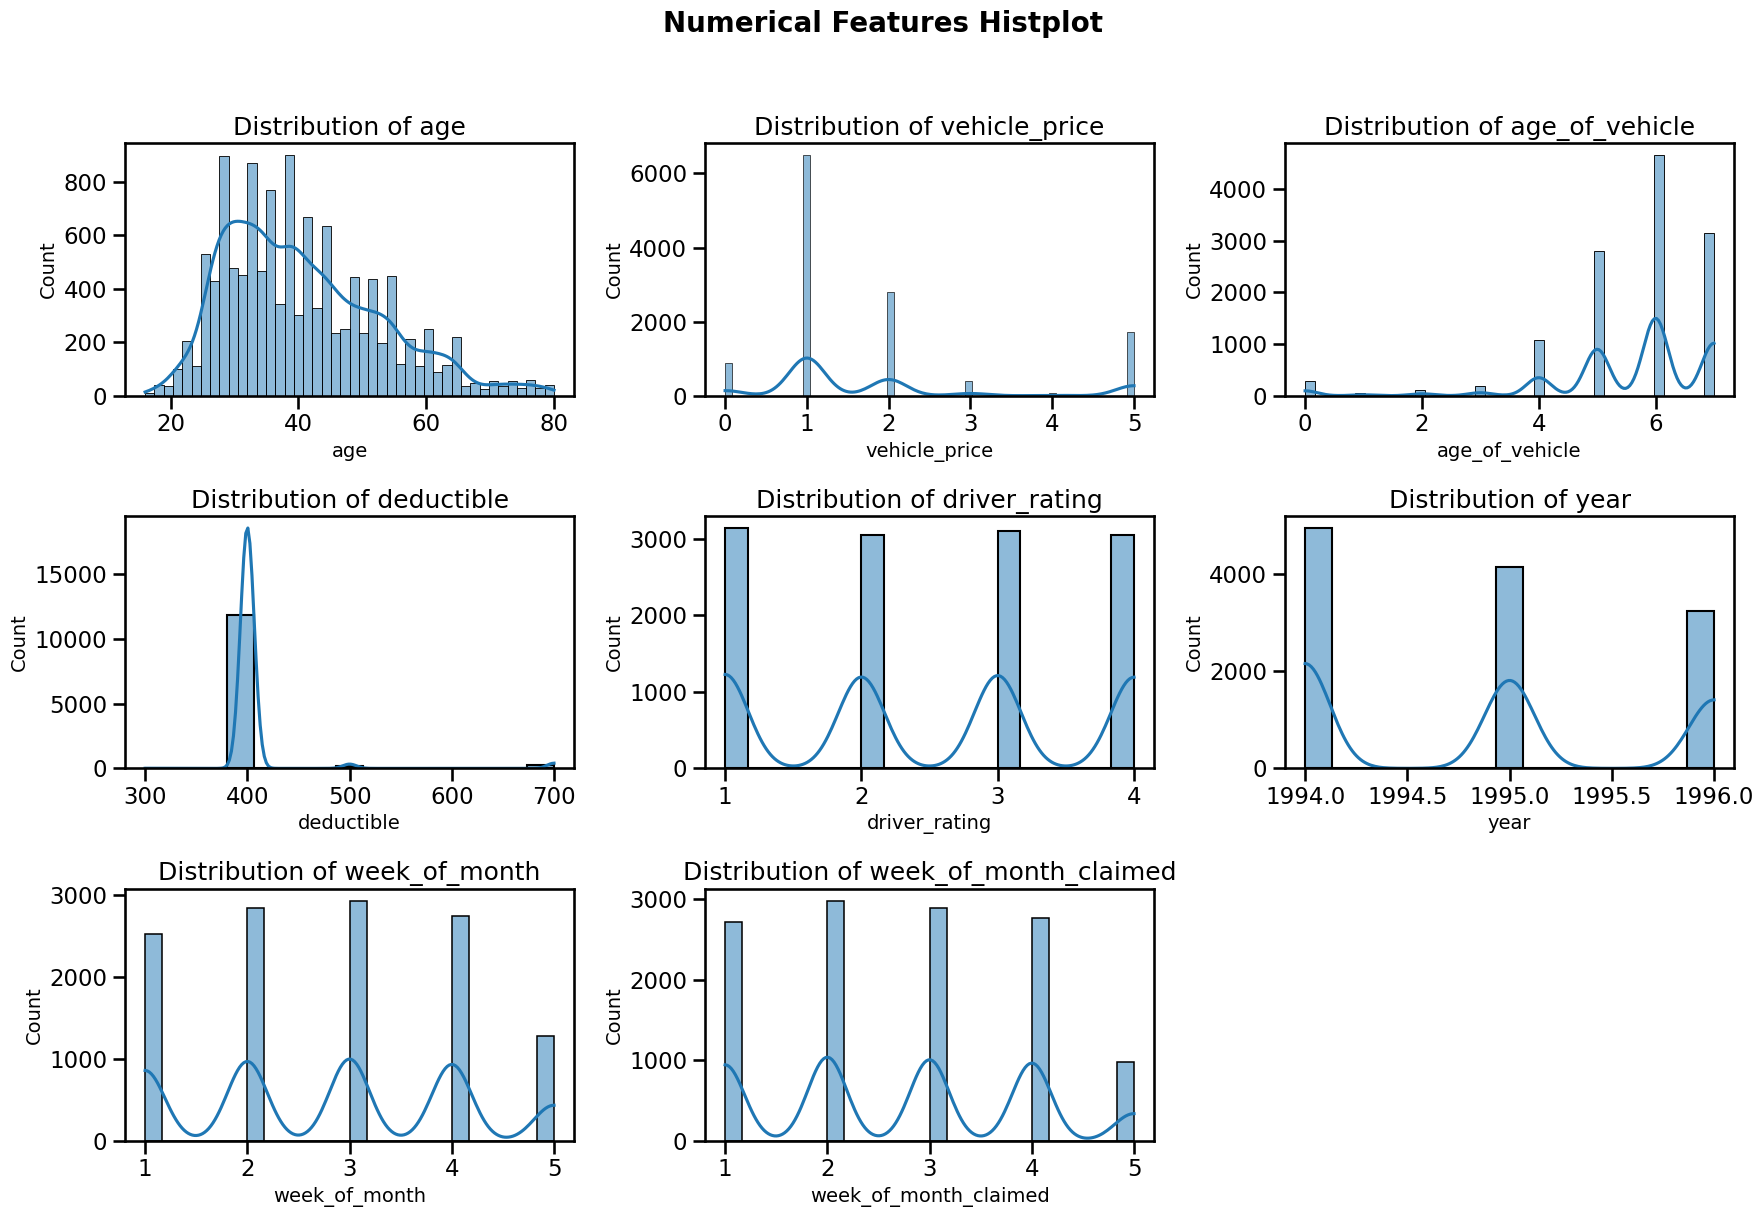

In [31]:
sns.set_context('talk')
plt.figure(figsize =(18,12))

for i, col in enumerate(numeric_cols):
    plt.subplot(3,3, i + 1)
    sns.histplot(df_train[col], kde=True)
    plt.title(f'Distribution of {col}', fontsize=18)
    plt.xlabel(col, fontsize=14)
    plt.ylabel('Count', fontsize=14)

plt.suptitle('Numerical Features Histplot', fontsize=20, fontweight='bold', y=1.02)
# plt.savefig('Numerical_features_histplot.png', dpi=150, bbox_inches='tight')  
plt.tight_layout()
plt.show()

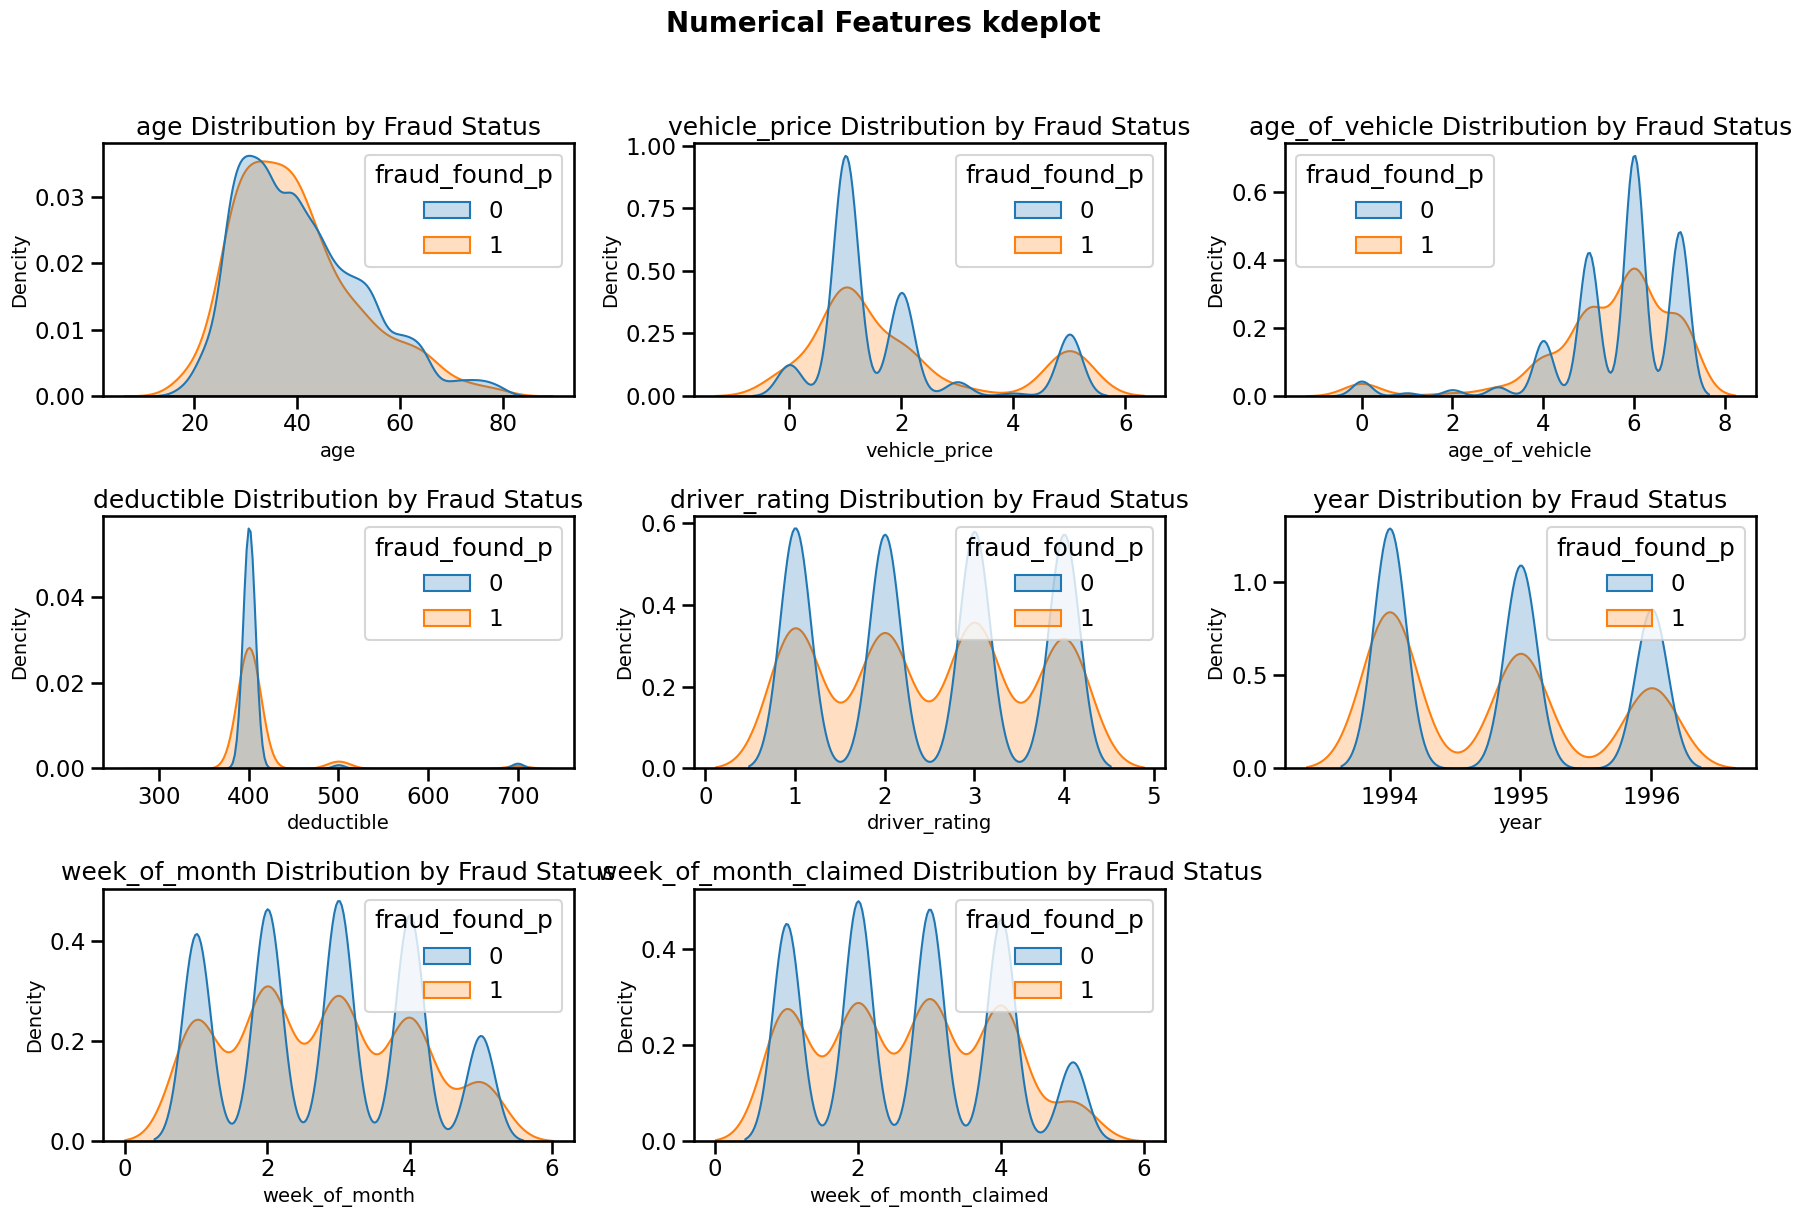

In [32]:
plt.figure(figsize =(18,12))

for i, col in enumerate(numeric_cols):
    plt.subplot(3,3, i + 1)
    sns.kdeplot(data=df_train, x=col, hue='fraud_found_p', fill=True, common_norm=False)
    plt.title(f'{col} Distribution by Fraud Status', fontsize=18)
    plt.xlabel(col, fontsize=14)
    plt.ylabel("Dencity", fontsize=14)

plt.suptitle('Numerical Features kdeplot', fontsize=20, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()



### Bivariate - numeric vs target
- Box plot


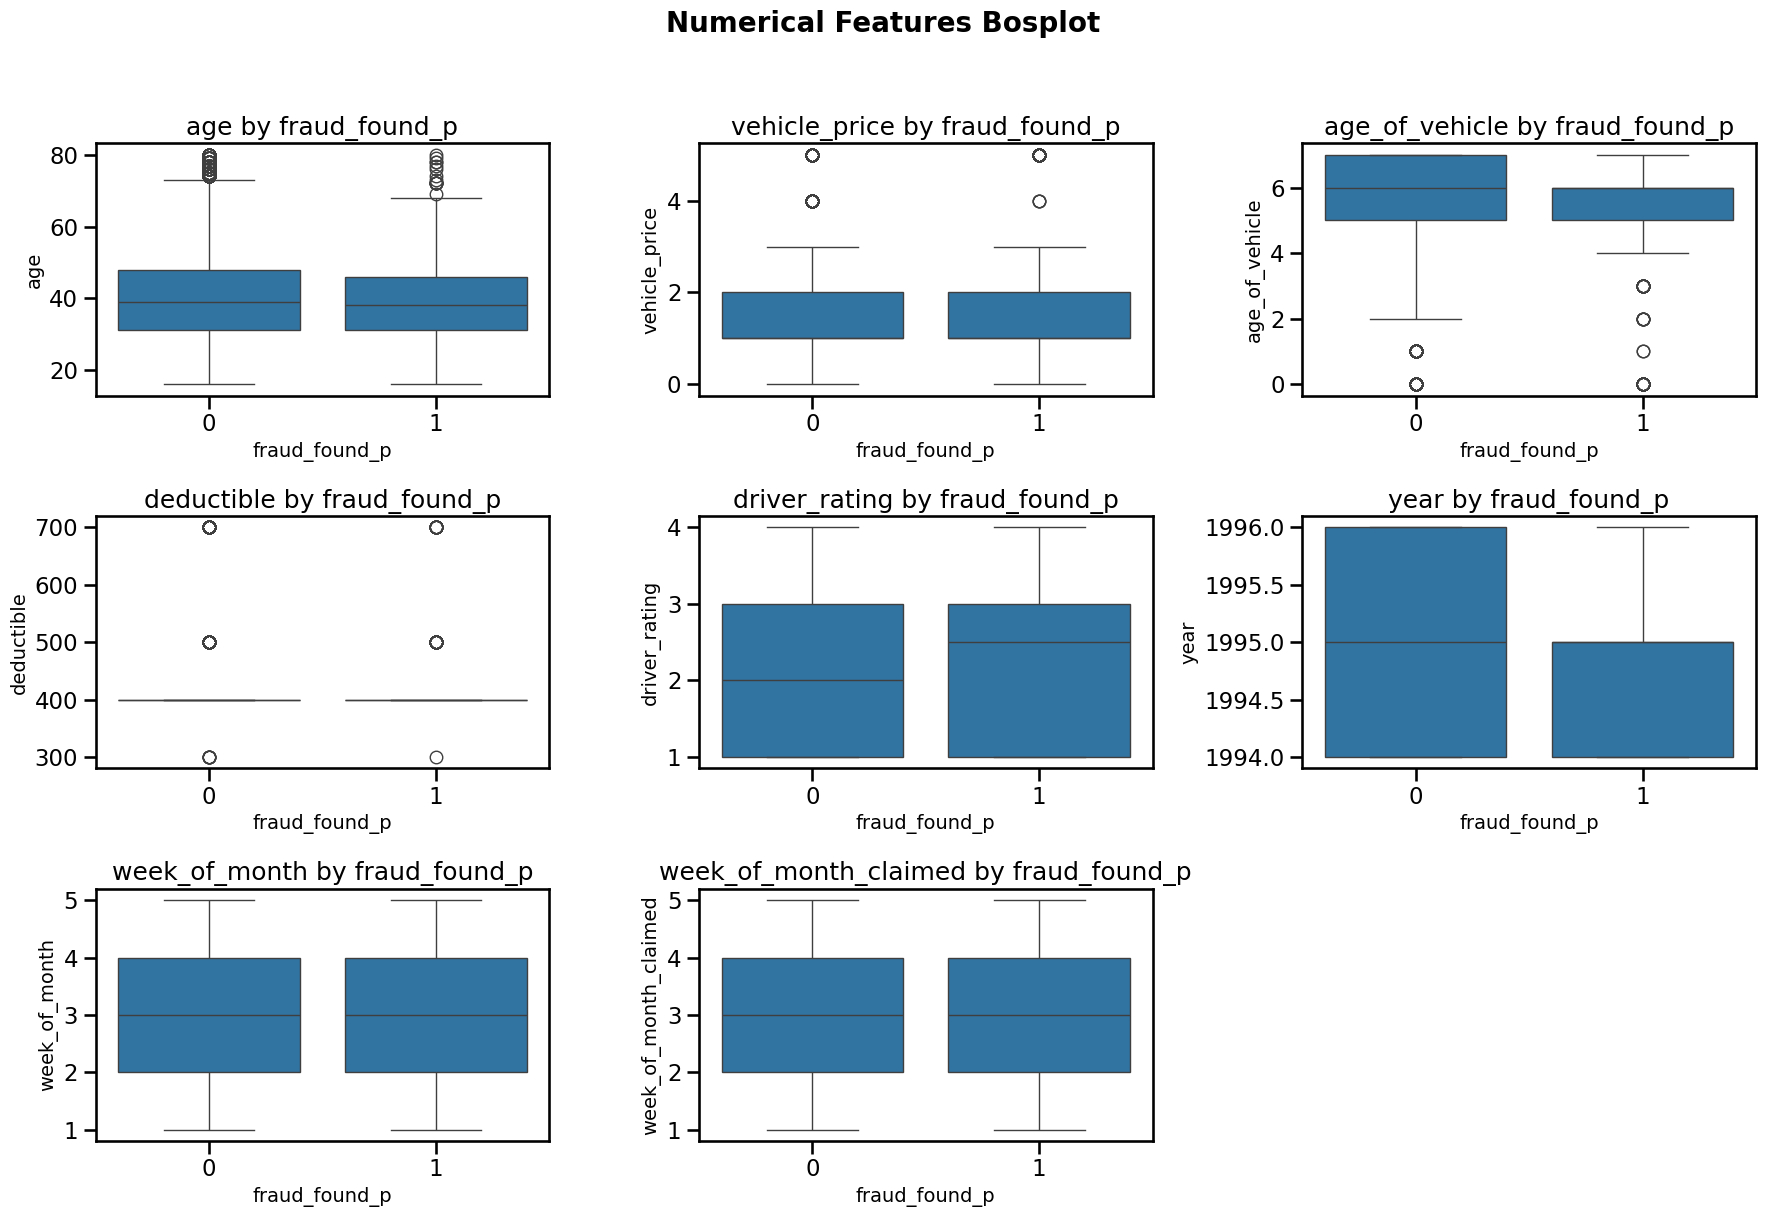

In [33]:
plt.figure(figsize =(18,12))

for i, col in enumerate(numeric_cols):
    plt.subplot(3,3, i + 1)
    sns.boxplot(x=target_col, y=col, data=df_train)
    plt.title(f'{col} by fraud_found_p', fontsize=18)
    plt.xlabel(target_col, fontsize=14)
    plt.ylabel(col, fontsize=14)

plt.suptitle('Numerical Features Bosplot', fontsize=20, fontweight='bold', y=1.02)
# plt.savefig('Numerical_features_bosplot.png', dpi=150, bbox_inches='tight')  
plt.tight_layout()
plt.show()

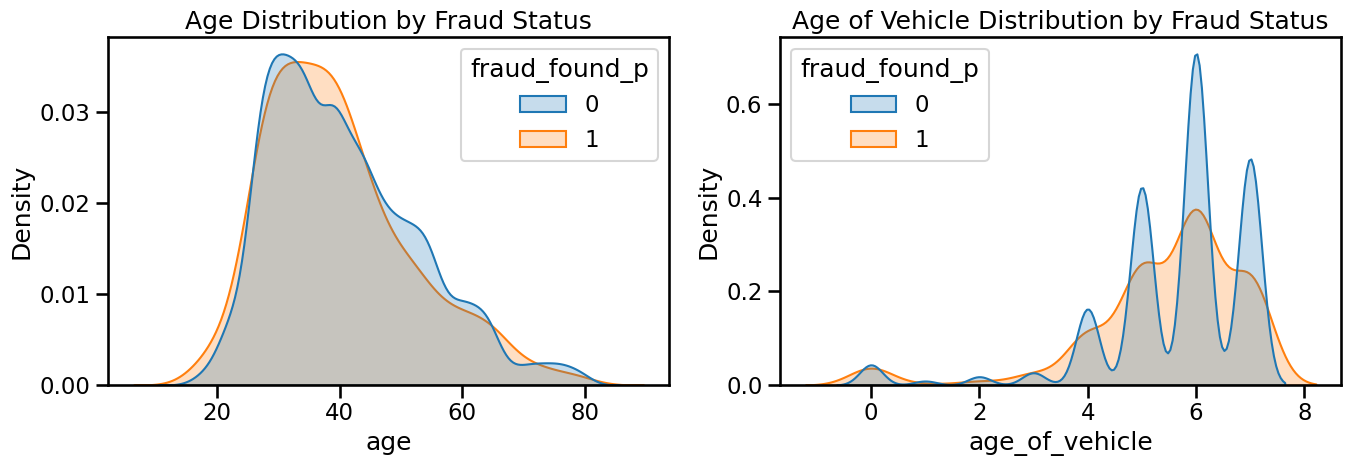

In [34]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
sns.kdeplot(data=df_train, x='age', hue='fraud_found_p', fill=True, common_norm=False)
plt.title('Age Distribution by Fraud Status')

plt.subplot(1, 2, 2)
sns.kdeplot(data=df_train, x='age_of_vehicle', hue='fraud_found_p', fill=True, common_norm=False)
plt.title('Age of Vehicle Distribution by Fraud Status')

plt.tight_layout()
plt.show()

### Univariate - categorical
- Counter plot

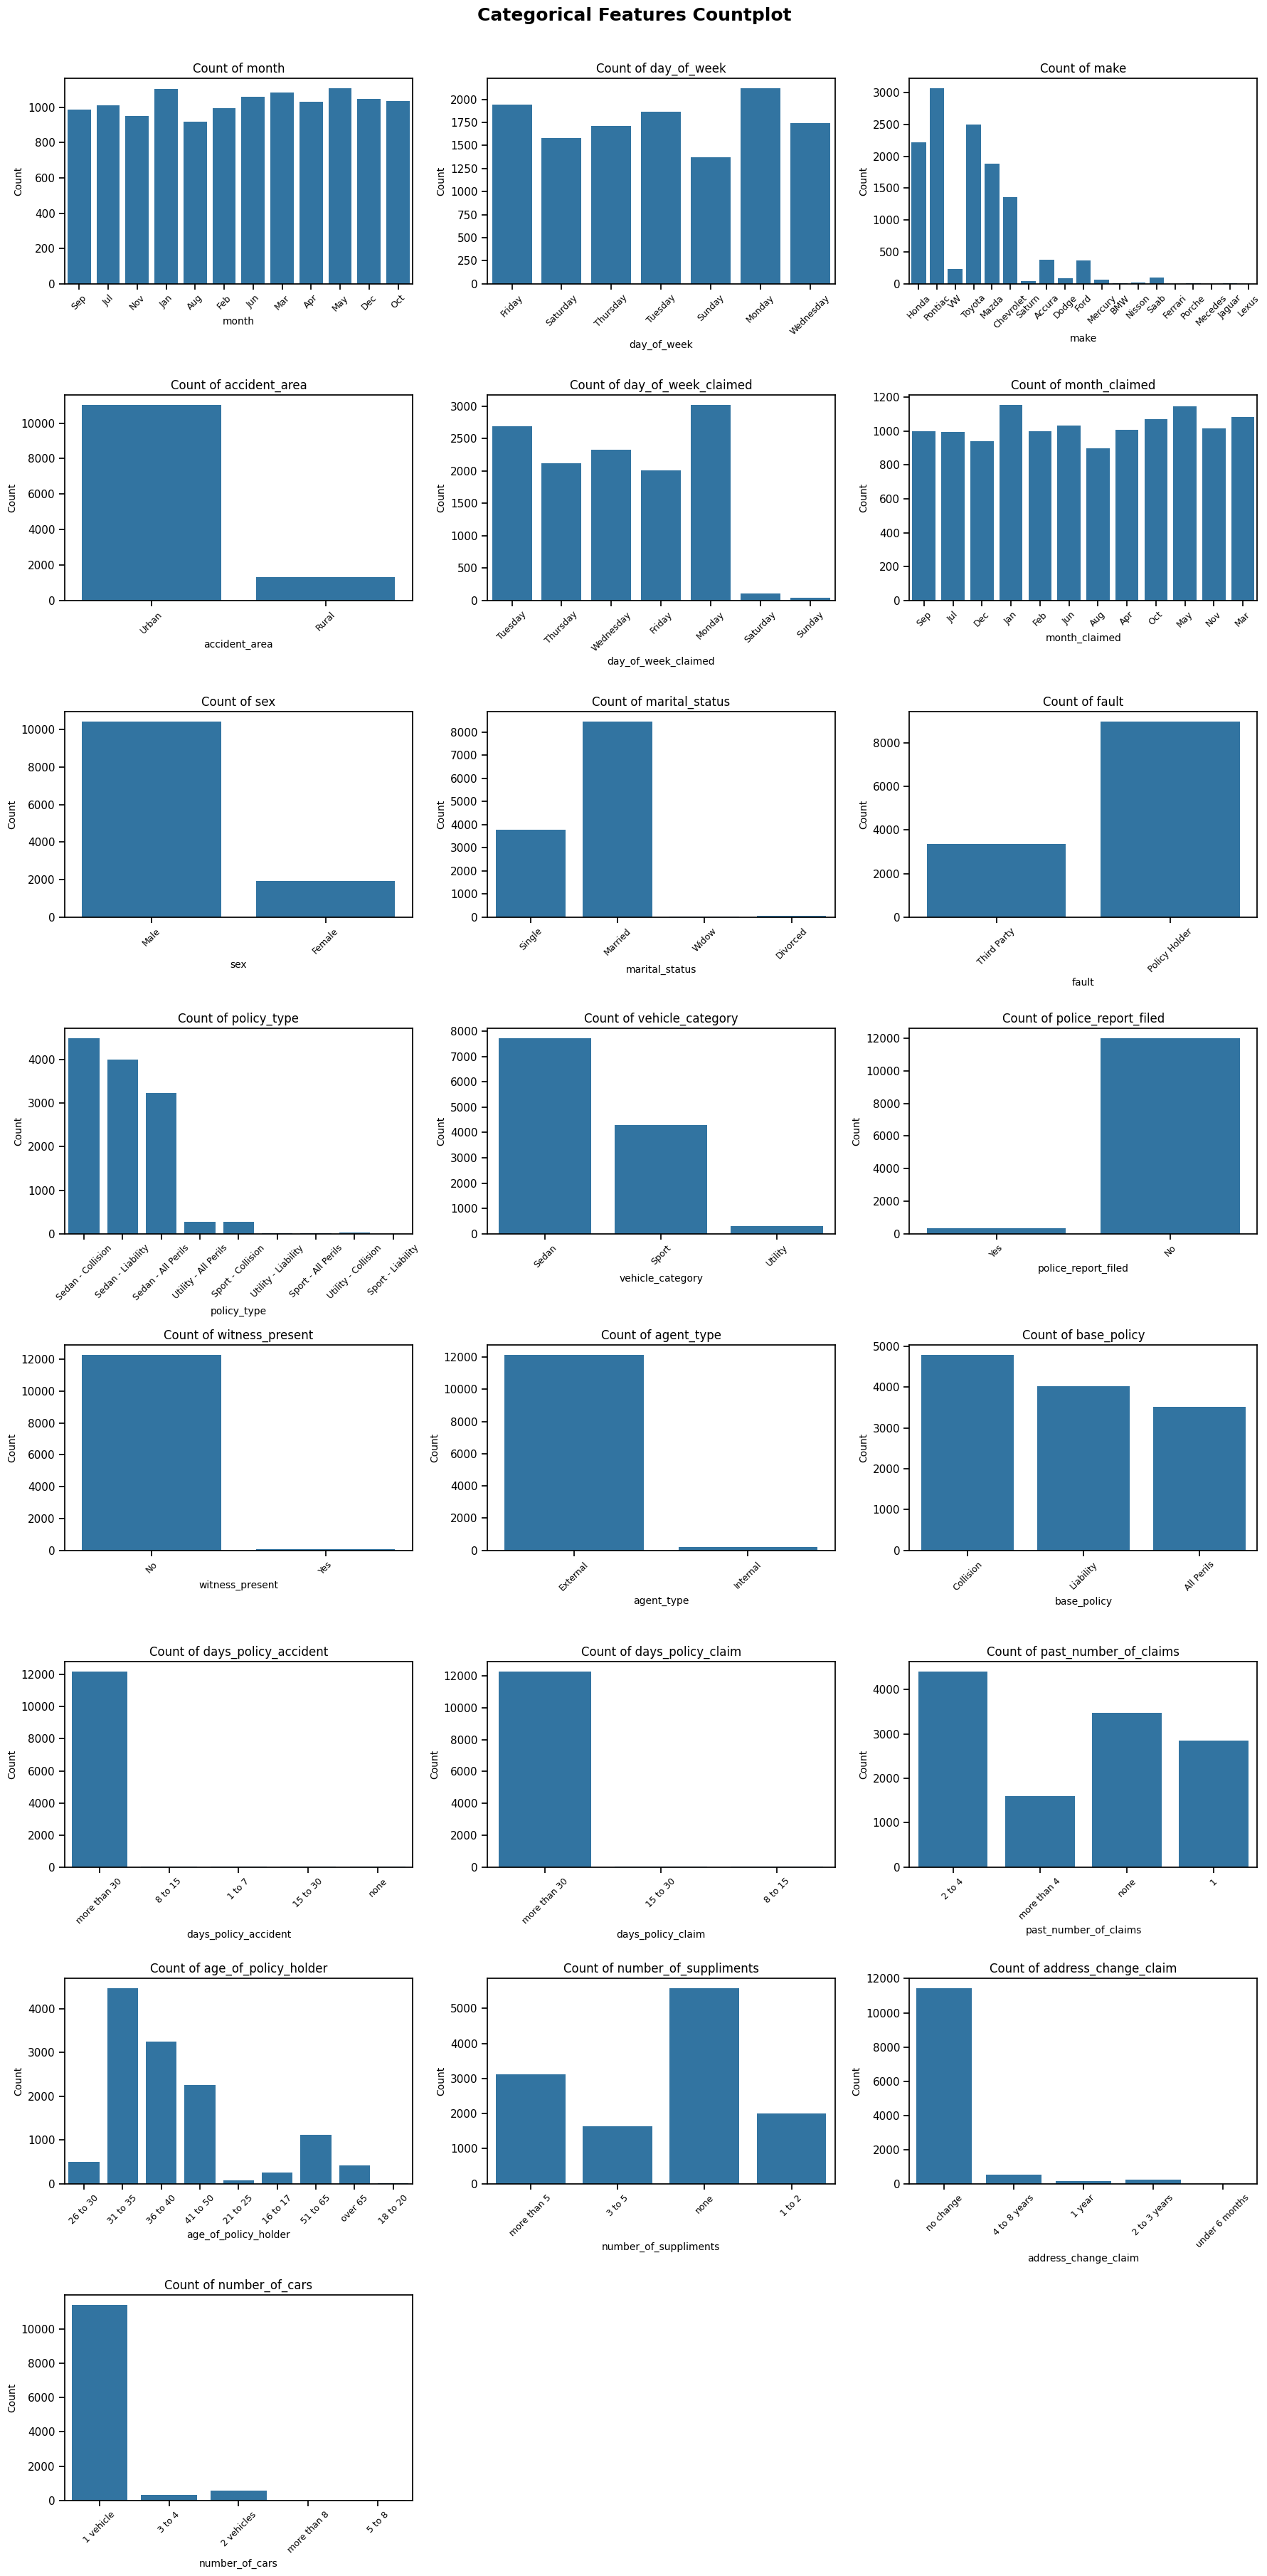

In [35]:
sns.set_context('notebook')  # 'talk' is likely too large for a 22-panel grid — scale down instead

n_cols = 3
n_rows = -(-len(categorical_cols) // n_cols)  # ceiling division, auto-fits any column count

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 6, n_rows * 4.5))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    sns.countplot(x=col, data=df_train, ax=axes[i])
    axes[i].set_title(f'Count of {col}', fontsize=12)
    axes[i].tick_params(axis='x', rotation=45, labelsize=9)
    axes[i].set_xlabel(col, fontsize=10)
    axes[i].set_ylabel('Count', fontsize=10)

# hide any unused subplot slots (when columns don't evenly fill the grid)
for j in range(len(categorical_cols), len(axes)):
    fig.delaxes(axes[j])

fig.suptitle('Categorical Features Countplot', fontsize=18, fontweight='bold', y=1.005)
# plt.savefig('Categorical_features_countplot.png', dpi=150, bbox_inches='tight')  
plt.tight_layout()
plt.show()

### Bivariate - categorical vs target (fraud rate per category)
- Bar plot

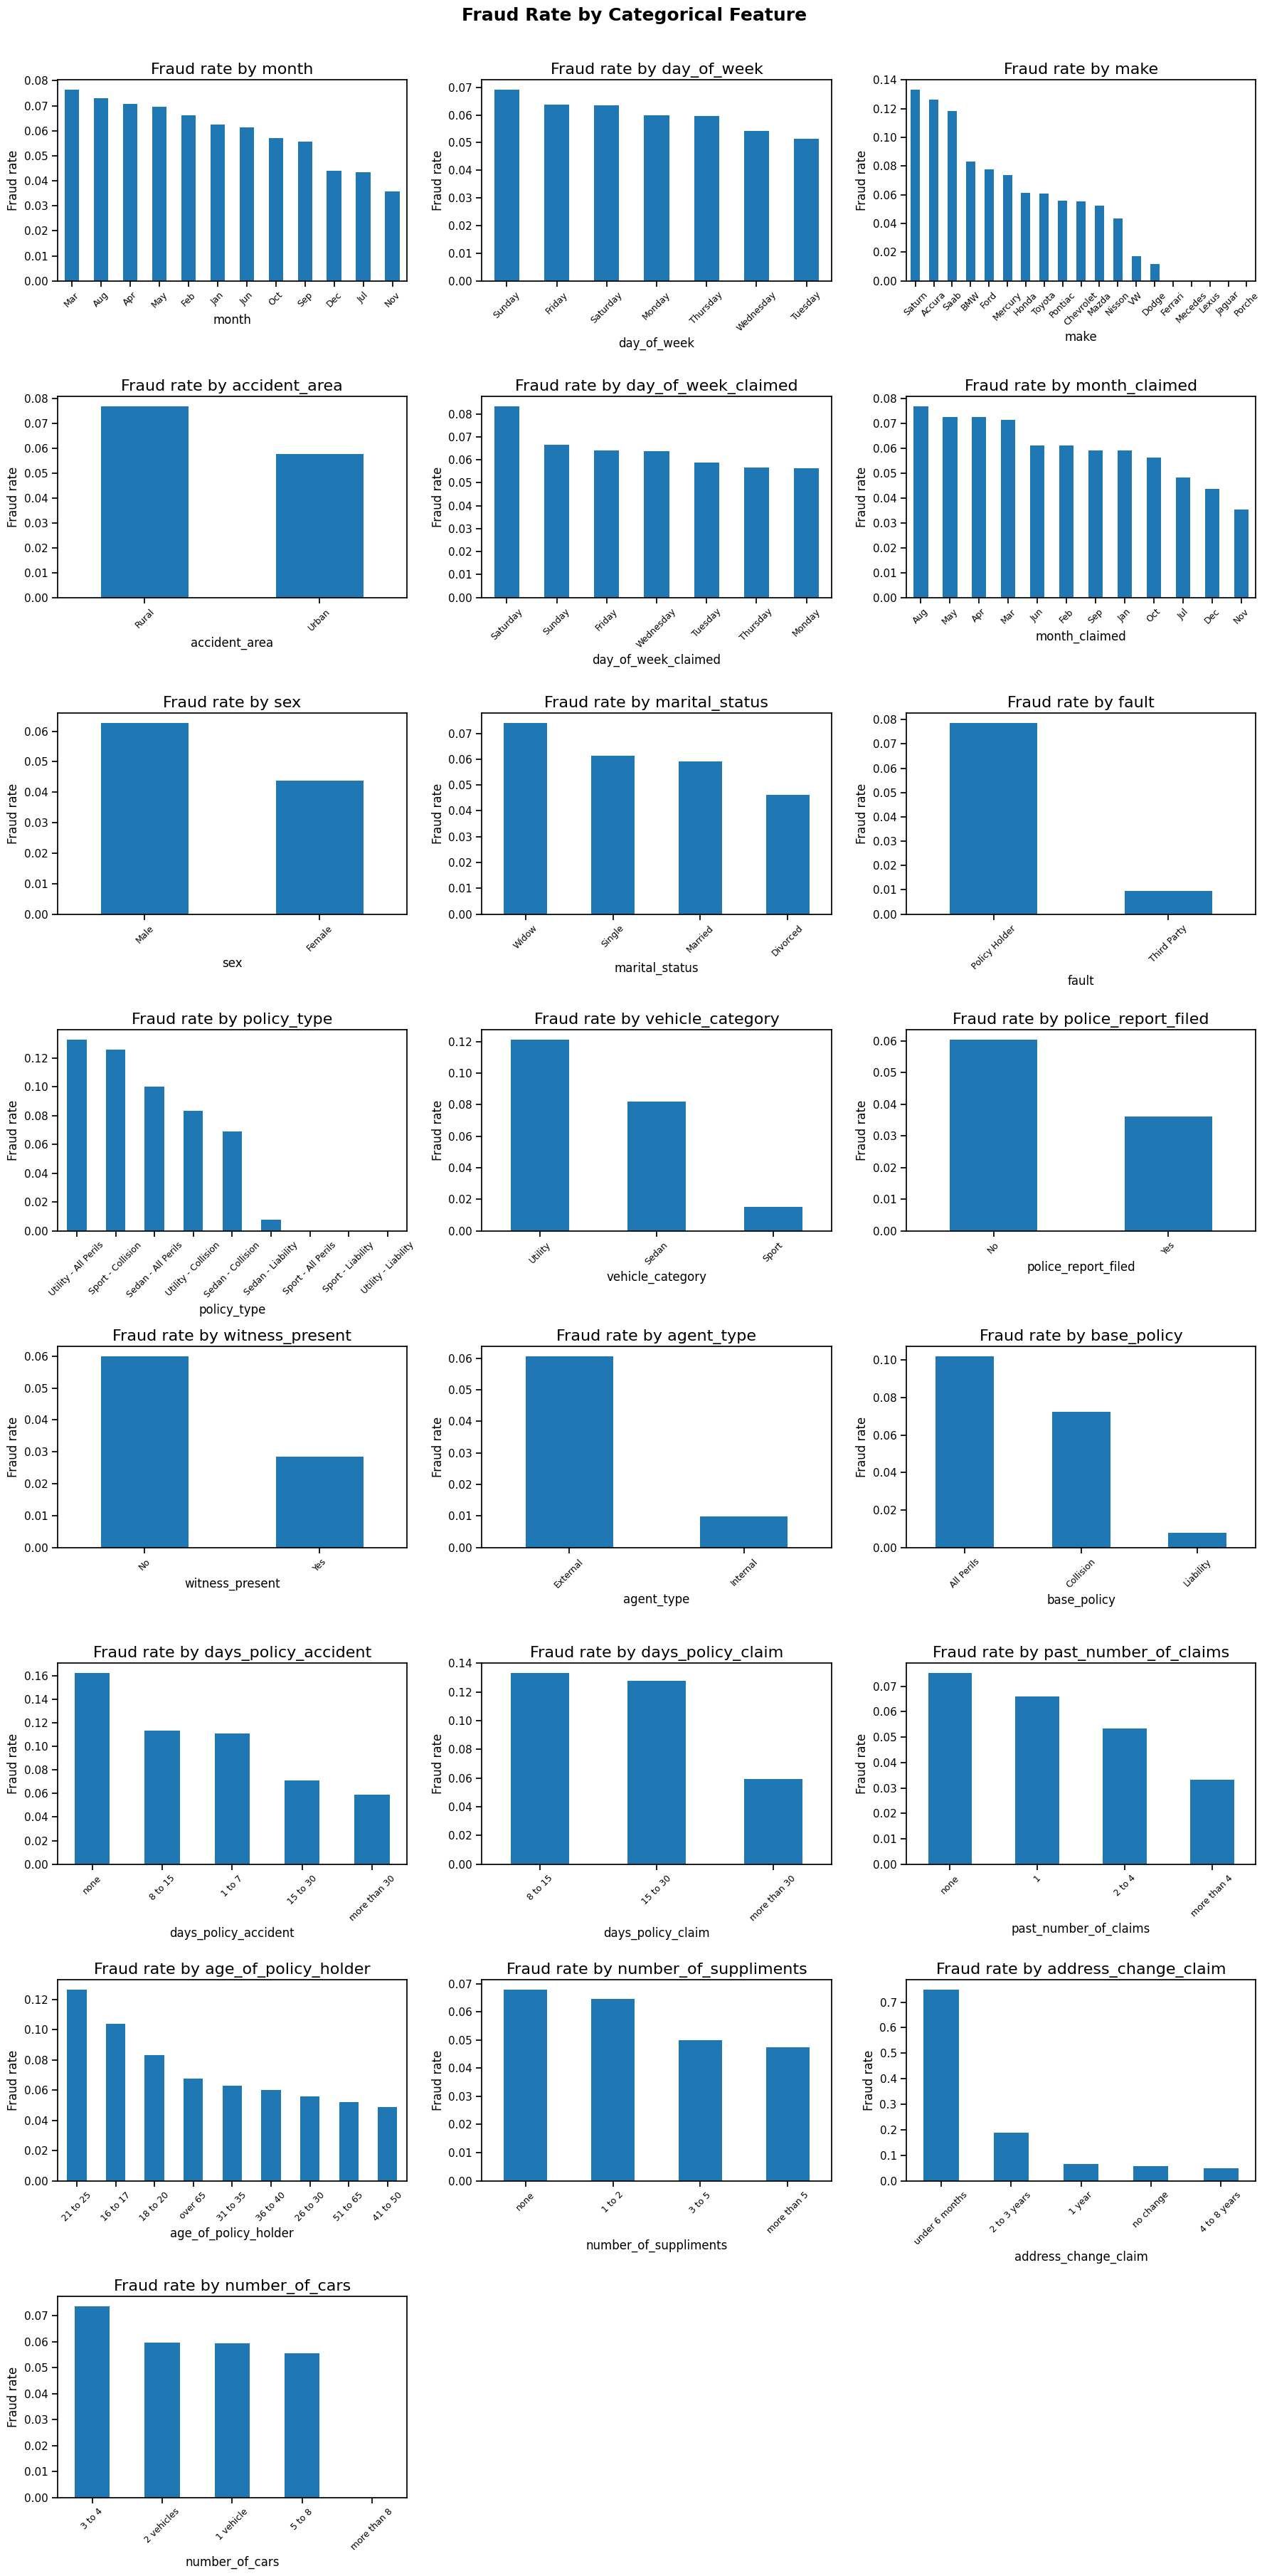

In [36]:
sns.set_context('notebook') 
import math

n_cols = 3
n_rows = math.ceil(len(categorical_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 6, n_rows * 4.5))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    rate = df_train.groupby(col)[target_col].mean().sort_values(ascending=False)
    rate.plot(kind='bar', ax=axes[i])
    axes[i].set_title(f'Fraud rate by {col}', fontsize=16)
    axes[i].tick_params(axis='x', rotation=45, labelsize=9)
    axes[i].set_xlabel(col, fontsize=12)
    axes[i].set_ylabel('Fraud rate', fontsize=12)

for j in range(len(categorical_cols), len(axes)):
    fig.delaxes(axes[j])

fig.suptitle('Fraud Rate by Categorical Feature', fontsize=18, fontweight='bold', y=1.005)
# plt.savefig('Categorical_features_barplot.png', dpi=150, bbox_inches='tight')  
plt.tight_layout()
plt.show()
plt.show()

### EDA Summary — Key Findings

Baseline fraud rate: ~5.99% (923 / 15,420). Every category's fraud rate below is
judged relative to this baseline, and only trusted when backed by a large enough
sample size.

#### Strong, reliable signal (solid sample sizes)
- **fault -** Policy Holder ~8% vs Third Party ~1% (9000 / 3400 rows), strongest single feature
- **vehicle_category -** Sport/Sedan meaningfully above Utility
- **policy_type / base_policy -** Collision/All Perils above Liability
- **age_of_policy_holder -** younger policyholders (21-25) show a higher fraud rate, clear downward trend
- **year -** fraud skews toward earlier years (1994), confirmed in both boxplot and KDE

#### Weak but real signal
- **age_of_vehicle -** fraud proportionally skews toward younger vehicles; visible in
  boxplot outliers and KDE, though overall shape is similar between groups

#### Mixed within-column (same column, different verdicts by category)
- **make -** Honda/Toyota/Mazda/Pontiac (1300-2500 rows each) show a real, modest
  fraud-rate spread (0.06 to 0.13) and are trustworthy. Saturn/Accura/BMW/VW
  (each <400 rows) show extreme-looking rates that are sample-size noise ignored.

#### Dramatic-looking rates that are sample-size artefacts, not signal
- **address_change_claim -** "under 6 months" spikes to ~0.75 fraud rate but has
  only ~100-200 rows vs ~11,500 in "no change" (which shows a low, unremarkable
  rate), not trustworthy
- **days_policy_accident**, **days_policy_claim -** same trap, ~12,000 rows crammed
  into "more than 30" bin, other bins too sparse to trust
- **marital_status -** ("Widow"), rare **make -** categories, same issue

#### No signal (flat across fraud/non-fraud)
age, vehicle_price, deductible (near-constant), driver_rating, week_of_month,
week_of_month_claimed, number_of_cars

#### Excluded from feature set entirely
- **rep_number -** Checked fraud rate is uniform (0.04 to 0.07) across all 16 reps.
Solid sample sizes (700-850 claims per rep) rule out small-sample noise as an
explanation.
- **policy_number -** unique row ID, not a feature


<h1 style="color:green">Feature Engineering, Feature Selection</h1>

<h1 style="color:green">Model Training</h1>

<h1 style="color:green">Model Evaluation</h1>